In [1]:
import numpy as np
import pandas as pd
from scipy.stats import *
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import seaborn as sns

In [65]:
data = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/all.cnv')
data['LEN'] = data['BP2'] - data['BP1'] + 1
data['CNV'] = data['CHR'].map(str) + ':'    \
              + data['BP1'].map(str) + '-'  \
              + data['BP2'].map(str) + '_'  \
              + data['TYPE'].map(str)
cnvAC = data['CNV'].value_counts()
cnvN  = data['IID'].value_counts().tolist() + \
          [0 for _ in range(32764)] # magic number: people called w/o cnv
data.head()

,FID,IID,CHR,BP1,BP2,TYPE,SCORE,SITES,LEN,CNV
0,1000016,1000016,1,195832997,195867743,1,0,34747,34747,1:195832997-195867743_1
1,1000021,1000021,1,12896983,12923962,1,0,26980,26980,1:12896983-12923962_1
2,1000057,1000057,1,25619569,25658903,1,0,39335,39335,1:25619569-25658903_1
3,1000098,1000098,1,25599041,25648747,1,0,49707,49707,1:25599041-25648747_1
4,1000103,1000103,1,25605537,25633210,3,0,27674,27674,1:25605537-25633210_3


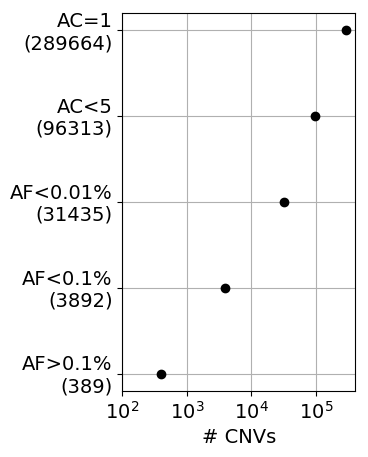

In [52]:
#sns.distplot(cnvAC[cnvAC < 51], bins=list(range(1,21)), kde=False, fit=gamma)
bins = [1,2,6,47,476,cnvAC.max()+1]
labs = ['AC=1', 'AC<5', 'AF<0.01%', 'AF<0.1%', 'AF>0.1%']
counts, bins = np.histogram(cnvAC.tolist(), bins=bins)
plt.figure(figsize=(3,5))
plt.rcParams.update({'font.size': 14})
#plt.semilogy(list(range(6)), counts, 'ko')
#plt.xticks(list(range(6)), labs, rotation='60', fontsize=12)
           #map(lambda (x,y): '{0}\n({1:.2E})'.format(x,y), zip(labs,counts)),
           #rotation='30')
plt.semilogx(list(reversed(counts)), list(range(len(bins)-1)), 'ko')
plt.yticks(list(range(len(bins)-1)), 
           map(lambda (x,y): '{0}\n({1})'.format(x,y), 
               reversed(zip(labs,counts))))
# plt.tick_params(axis='y', which='both', labelleft='off', labelright='on')
plt.xticks([10**x for x in range(2,6)])
plt.xlabel('# CNVs')
plt.grid()
plt.show()

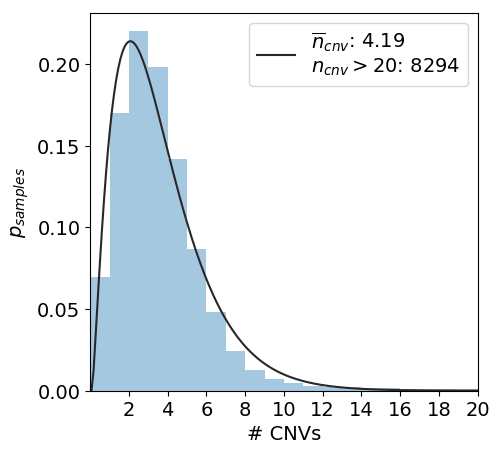

In [84]:
plt.figure(figsize=(5,5))
sns.distplot(map(lambda n: n+0.5, filter(lambda x: x < 21, cnvN)), 
             bins=list(range(21)), kde=False, fit=gamma)
plt.legend(['$\overline{n}_{cnv}$: ' + '{:.2f}'.format(np.mean(cnvN)) + 
            '\n$n_{cnv}>20$: ' + str(sum([x > 20 for x in cnvN]))])
plt.xticks(range(2,21,2)), plt.xlim((0,20))
plt.xlabel('# CNVs'), plt.ylabel('$p_{samples}$')
plt.show()

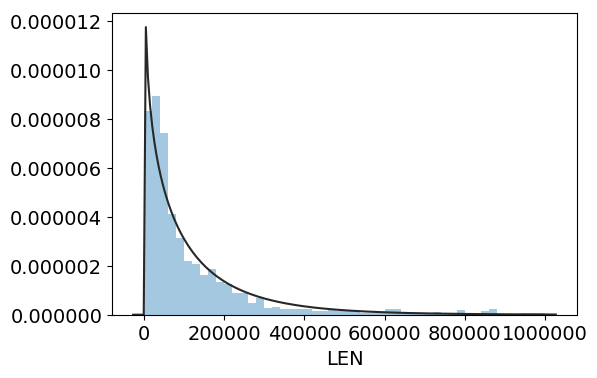

In [61]:
sns.distplot(data[data['LEN'] < 10**6].loc[:,'LEN'], fit=weibull_min, kde=False)
plt.show()

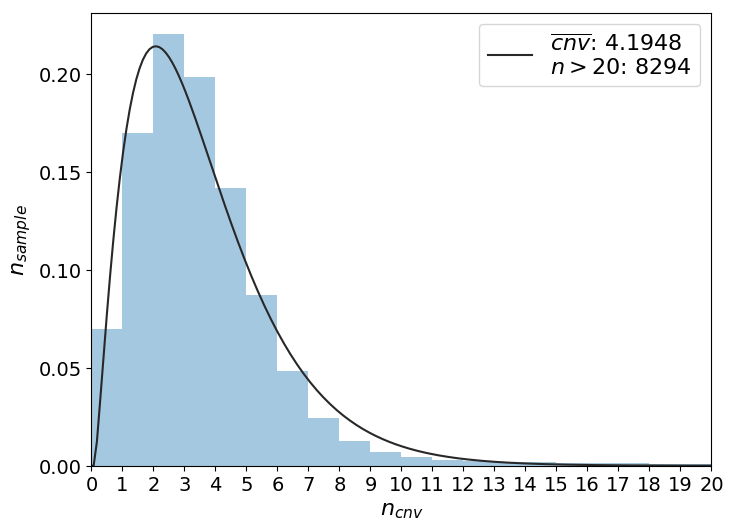

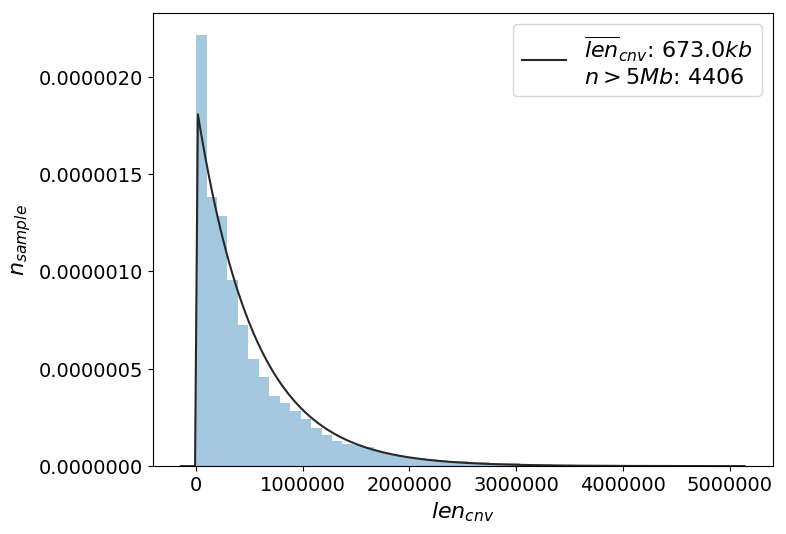

In [54]:
# plot histogram of CNV count, length per individual
cnv_counts, cnv_len = {}, {}
with open('/oak/stanford/groups/jpriest/cnv_ukb/all.cnv', 'r') as f:
    for i,line in enumerate(f):
        if i == 0:
            continue
        iid = line.split()[0]
        if iid not in cnv_counts:
            cnv_counts[iid] = 0
            cnv_len[iid] = 0
        cnv_counts[iid] += 1
        cnv_len[iid] += int(line.split()[4]) - int(line.split()[3])

# number of zeros: $(wc -l ukb.fam) - 100*n_batches - len(cnv_counts)
count_list = cnv_counts.values() + [0 for _ in range(32764)]
len_list   = cnv_len.values() + [0 for _ in range(32764)]
# display
plt.clf()
plt.figure(figsize=(8,6))
sns.distplot(filter(lambda x: x < 21, map(lambda i:i + 0.5, count_list)), bins=list(range(21)),
             fit=gamma, kde=False)
#n, bins, patches = plt.hist(count_list, bins = list(range(21)))
plt.xticks(range(21))
plt.legend(['$\overline{cnv}$: ' + '{:.4f}'.format(np.mean(count_list)) + '\n$n>20$: ' + 
            str(sum([x > 20 for x in cnv_counts.values()]))],fontsize=16)
plt.xlabel('$n_{cnv}$', fontsize=16)
plt.xlim((0,20))
plt.ylabel('$n_{sample}$', fontsize=16)
# plt.savefig('hist.png')
plt.show()

# display2
plt.clf(), plt.figure(figsize=(8,6))
sns.distplot(filter(lambda x: x <  5*10**6, len_list), bins=51, fit=expon, kde=False)
plt.legend(['$\overline{len}_{cnv}$: ' + '{:.1f}$kb$'.format(np.mean(len_list)/1000.0) + '\n$n>5Mb$: ' + 
            str(sum([x > 5*10**6 for x in cnv_len.values()]))],fontsize=16)
plt.xlabel('$len_{cnv}$', fontsize=16)
plt.ylabel('$n_{sample}$', fontsize=16)
plt.show()

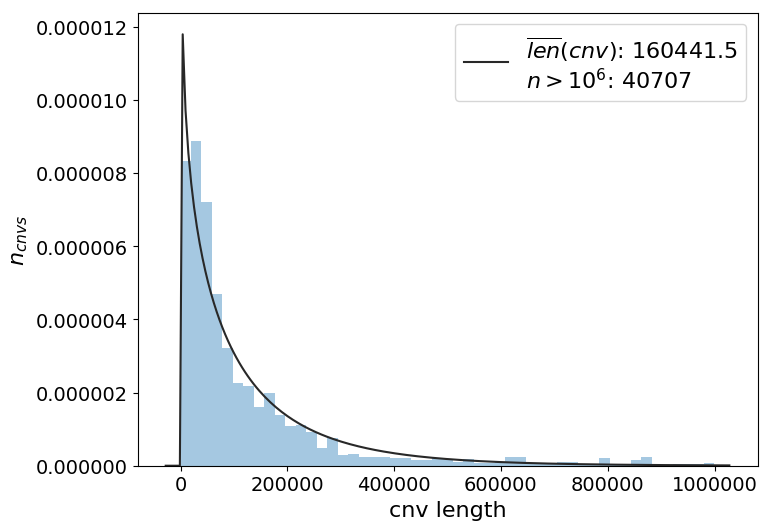

In [55]:
with open('/oak/stanford/groups/jpriest/cnv_ukb/all.cnv', 'r') as f:
    cnv_lens = [int(line.split()[4])-int(line.split()[3]) for i,line in enumerate(f) if i>0]

plt.figure(figsize=(8,6))
sns.distplot(filter(lambda i: i<=10**6, cnv_lens), bins=51, kde=False, fit=weibull_min)
# n, bins, patches = plt.hist([x for x in cnv_lens if x <= 10**6], bins = 51)
plt.legend(['$\overline{len}(cnv)$: ' + '{:.1f}'.format(np.mean(cnv_lens)) + '\n$n>10^{6}$: ' + 
            str(sum([x > 10**6 for x in cnv_lens]))],fontsize=16)
plt.xlabel('cnv length', fontsize=16)
plt.ylabel('$n_{cnvs}$', fontsize=16)
# plt.savefig('hist.png')
plt.show()

In [56]:
sum([i < 5 and i > 0 for i in count_list])/float(len([i != 0 for i in count_list]))

0.7167347741984106

In [57]:
len(count_list)

477676

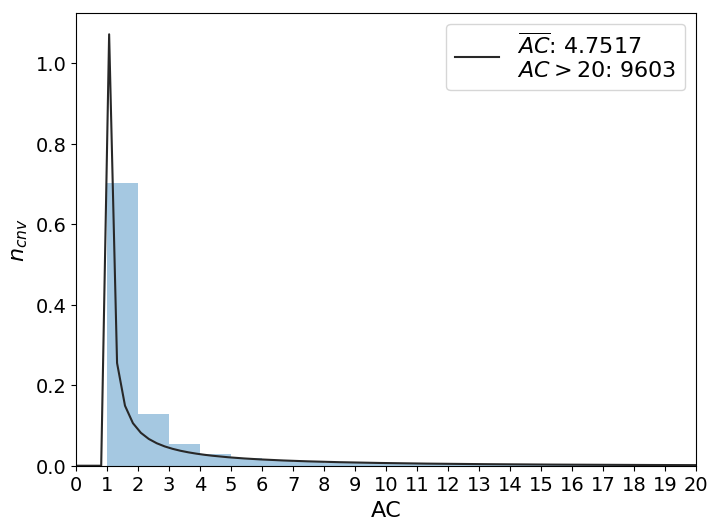

In [58]:
# get unique counts of cnv
cnv_freq = {}
with open('/oak/stanford/groups/jpriest/cnv_ukb/all.cnv', 'r') as f:
    for line in f:
        # FID     IID     CHR     BP1     BP2     TYPE    SCORE   SITES
        cnv = '_'.join(line.split()[2:6])
        if cnv not in cnv_freq:
            cnv_freq[cnv] = 0
        cnv_freq[cnv] += 1

plt.clf()
plt.figure(figsize=(8,6))
sns.distplot(filter(lambda x: x < 51, cnv_freq.values()), bins=list(range(1,21)), kde=False, fit=gamma)
# n, bins, patches = plt.hist(cnv_freq.values(), bins = list(range(1,21)))
plt.xticks(range(21))
plt.legend(['$\overline{AC}$: ' + '{:.4f}'.format(np.mean(cnv_freq.values())) + '\n$AC>20$: ' + 
            str(sum([x > 20 for x in cnv_freq.values()]))],fontsize=16)
plt.xlabel('AC', fontsize=16)
plt.ylabel('$n_{cnv}$', fontsize=16)
plt.xlim((0,20))
# plt.savefig('hist.png')
plt.show()

In [59]:
print(cnv_freq.values().count(1), len(cnv_freq), float(cnv_freq.values().count(1))/len(cnv_freq))

(289665, 421694, 0.6869080423245292)


In [60]:
(np.mean(np.array(cnv_freq.values())**2), np.mean(np.array(cnv_freq.values())**2)/len(cnv_freq))

(4914.4230792944645, 0.011654002853477794)